# Spiking Neural Network on N-MNIST

This notebook implements a **convolutional spiking neural network (SNN)** trained on the **N-MNIST** event-based dataset.  
Event streams are converted into temporal frames and processed using **Leaky Integrate-and-Fire (LIF)** neurons with surrogate-gradient learning.

The notebook covers data preprocessing, event-based visualizations, model definition, training, and evaluation.


In [ ]:
# !pip -q install tonic snntorch torch torchvision torchaudio --upgrade

## Imports and seeding

In [21]:
import os
import math
import time
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import tonic
import tonic.transforms as T

import snntorch as snn
from snntorch import surrogate

import numpy as np
import matplotlib.pyplot as plt


In [13]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Config

In [17]:
DATA_DIR = "./data"
BATCH_SIZE = 64
NUM_WORKERS = 2

TIME_BINS = 20
SENSOR_SIZE = (34, 34, 2)  # (H, W, polarity)

EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4

BETA = 0.95
SPIKE_SLOPE = 25.0


## Dataset

In [18]:
to_frames = T.ToFrame(sensor_size=SENSOR_SIZE, n_time_bins=TIME_BINS)


def normalize_frames(frames):
    frames = torch.as_tensor(frames, dtype=torch.float32)
    m = frames.max()
    return frames if m <= 0 else frames / m


class NMNISTFrames(torch.utils.data.Dataset):
    def __init__(self, train=True, root=DATA_DIR, transform=to_frames):
        self.ds = tonic.datasets.NMNIST(save_to=root, train=train)
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        events, label = self.ds[idx]
        frames = normalize_frames(self.transform(events))

        # tonic versions differ: [T,H,W,C] vs [T,C,H,W]
        if frames.ndim != 4:
            raise ValueError(f"Unexpected frames shape: {tuple(frames.shape)}")

        if frames.shape[-1] == 2 and frames.shape[1] == 34 and frames.shape[2] == 34:
            frames = frames.permute(0, 3, 1, 2).contiguous()  # [T,C,H,W]

        return frames, int(label)


train_ds = NMNISTFrames(train=True)
test_ds = NMNISTFrames(train=False)

len(train_ds), len(test_ds)

  0%|          | 0/1011893601 [00:00<?, ?it/s]

Extracting ./data/NMNIST/train.zip to ./data/NMNIST


  0%|          | 0/169674850 [00:00<?, ?it/s]

Extracting ./data/NMNIST/test.zip to ./data/NMNIST


(60000, 10000)

# Visualisations

## Time Surface (decayed recency map)
for each pixel (and polarity), store the timestamp of the last event, visualized after an exponential decay so “recent” events are brighter

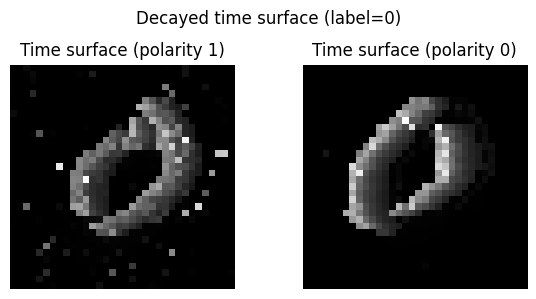

In [22]:
# Pull raw events from the dataset
events, label = train_ds.ds[0]

H, W, _ = SENSOR_SIZE
tau_ms = 30.0

# Convert timestamps to milliseconds
t_us = events["t"].astype(np.float64)
t_ms = t_us / 1000.0

t_now = t_ms.max()

# last timestamp per pixel per polarity
last = np.full((2, H, W), -np.inf, dtype=np.float64)

x = events["x"].astype(np.int64)
y = events["y"].astype(np.int64)
p = events["p"].astype(np.int64)

# Keep last time at each (p, y, x)
for xi, yi, pi, ti in zip(x, y, p, t_ms):
    last[pi, yi, xi] = ti

# Exponential decay: exp(-(t_now - t_last)/tau)
age = t_now - last
surf = np.exp(-age / tau_ms)
surf[~np.isfinite(last)] = 0.0

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(surf[1], cmap="gray")
ax[0].set_title("Time surface (polarity 1)")
ax[0].axis("off")

ax[1].imshow(surf[0], cmap="gray")
ax[1].set_title("Time surface (polarity 0)")
ax[1].axis("off")

fig.suptitle(f"Decayed time surface (label={label})")
plt.tight_layout()
plt.show()

## Voxel Grid (spatiotemporal volume slices)
discretizes events into (x, y, t) bins with separate channels for polarity

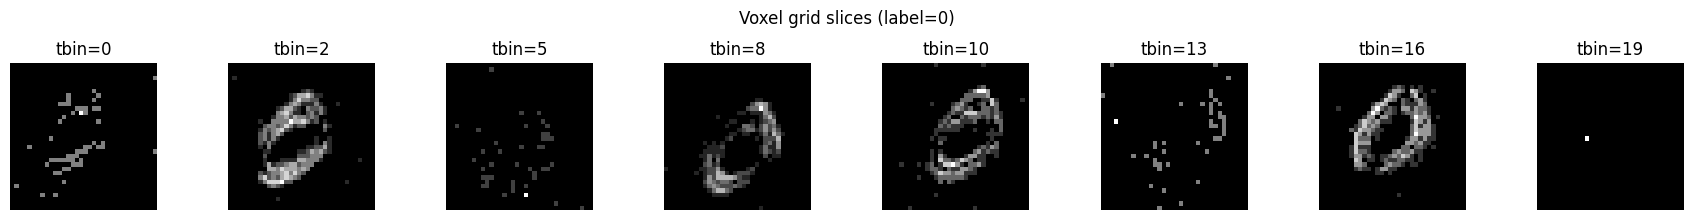

In [23]:
events, label = train_ds.ds[0]

H, W, _ = SENSOR_SIZE
T_bins = TIME_BINS

t = events["t"].astype(np.float64)
t0, t1 = t.min(), t.max()
den = (t1 - t0) if (t1 > t0) else 1.0

# Map each event to a time bin [0, T_bins-1]
tb = np.floor((t - t0) / den * (T_bins - 1)).astype(np.int64)
tb = np.clip(tb, 0, T_bins - 1)

x = events["x"].astype(np.int64)
y = events["y"].astype(np.int64)
p = events["p"].astype(np.int64)

vox = np.zeros((T_bins, 2, H, W), dtype=np.float32)
for xi, yi, pi, ti in zip(x, y, p, tb):
    vox[ti, pi, yi, xi] += 1.0

# Normalize per-sample for visualization
m = vox.max()
if m > 0:
    vox = vox / m

# Show a handful of time slices (collapsed across polarity for compactness)
show = min(T_bins, 8)
idxs = np.linspace(0, T_bins - 1, show).astype(int)

fig, axes = plt.subplots(1, show, figsize=(2.2 * show, 2.2))
if show == 1:
    axes = [axes]

for ax, i in zip(axes, idxs):
    img = vox[i].sum(axis=0)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"tbin={i}")
    ax.axis("off")

fig.suptitle(f"Voxel grid slices (label={label})")
plt.tight_layout()
plt.show()


## Dataloaders

In [28]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

x, y = next(iter(train_loader))
x.shape, y.shape, y[:10]

(torch.Size([64, 20, 2, 34, 34]),
 torch.Size([64]),
 tensor([3, 7, 9, 9, 6, 7, 2, 3, 1, 4]))

## Model Overview

The model is a **convolutional spiking neural network (SNN)** operating on N-MNIST event frames of shape **(T, 2, 34, 34)**, where each time bin corresponds to one simulation step.

It consists of two convolutional layers (**2->16** and **16->32** channels, 3×3 kernels), each followed by **Leaky Integrate-and-Fire (LIF)** activations and **2x2 max pooling**, reducing the spatial resolution to **8x8**. The resulting features are flattened and passed to a fully connected spiking layer with **10 output neurons**, one per digit class.

LIF neurons integrate input over time with membrane decay and emit spikes when a threshold is crossed. During training, **surrogate gradients** are used to enable backpropagation through time. Classification is performed using **rate coding**, by averaging output spikes across time and selecting the most active neuron.


In [31]:
class ConvSNN(nn.Module):
    def __init__(self, beta=BETA, slope=SPIKE_SLOPE):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid(slope=slope)

        self.conv1 = nn.Conv2d(2, 16, 3, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.MaxPool2d(2)  # 34 -> 17

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.MaxPool2d(2)  # 17 -> 8

        self.fc = nn.Linear(32 * 8 * 8, 10)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        # expect [B,T,C,H,W]
        b, t, c, h, w = x.shape

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_seq = []
        mem_seq = []

        for i in range(t):
            xi = x[:, i]  # [B,C,H,W]

            cur1 = self.conv1(xi)
            spk1, mem1 = self.lif1(cur1, mem1)
            x1 = self.pool1(spk1)

            cur2 = self.conv2(x1)
            spk2, mem2 = self.lif2(cur2, mem2)
            x2 = self.pool2(spk2)

            x2 = x2.view(b, -1)
            cur3 = self.fc(x2)
            spk3, mem3 = self.lif3(cur3, mem3)

            spk_seq.append(spk3)
            mem_seq.append(mem3)

        spk_out = torch.stack(spk_seq, dim=1)  # [B,T,10]
        mem_out = torch.stack(mem_seq, dim=1)  # [B,T,10]
        return spk_out, mem_out


model = ConvSNN().to(device)
model

ConvSNN(
  (conv1): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (lif1): Leaky()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (lif2): Leaky()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
  (lif3): Leaky()
)

In [33]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()


def as_btc_hw(x):
    # ensure [B,T,C,H,W]; some collations can yield [T,B,C,H,W]
    if x.ndim != 5:
        raise ValueError(f"Expected 5D tensor, got {tuple(x.shape)}")
    if x.shape[0] == TIME_BINS and x.shape[1] != TIME_BINS:
        x = x.permute(1, 0, 2, 3, 4).contiguous()
    return x


@torch.no_grad()
def batch_acc(spk_out, y):
    rates = spk_out.mean(dim=1)          # [B,10]
    preds = rates.argmax(dim=1)
    return (preds == y).float().mean().item()


def run_epoch(model, loader, train=True):
    model.train(train)

    total_loss = 0.0
    total_acc = 0.0
    n = 0

    for x, y in loader:
        x = as_btc_hw(x).to(device)
        y = y.to(device)

        spk_out, mem_out = model(x)
        rates = spk_out.mean(dim=1)      # rate coding -> logits

        loss = criterion(rates, y)

        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += batch_acc(spk_out, y) * bs
        n += bs

    return total_loss / n, total_acc / n

## Training Overview

The network is trained using **supervised learning** with backpropagation through time.  
Input event frames are processed sequentially over **T** time steps, and neuron spikes are differentiated using **surrogate gradients**.

At each iteration, output spikes are **averaged over time** to form class logits, and a **cross-entropy loss** is applied against the ground-truth digit label. Model parameters are optimized using the **AdamW** optimizer.

Training is performed in mini-batches, and performance is evaluated using classification accuracy computed from spike rates on a held-out test set.


In [34]:
best = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    test_loss, test_acc = run_epoch(model, test_loader, train=False)

    best = max(best, test_acc)
    dt = time.time() - t0

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"test loss {test_loss:.4f} acc {test_acc:.4f} | "
        f"time {dt:.1f}s"
    )

print("Best test acc:", best)

Epoch 01/5 | train loss 1.7451 acc 0.7806 | test loss 1.6456 acc 0.8666 | time 117.9s
Epoch 02/5 | train loss 1.6144 acc 0.9019 | test loss 1.5978 acc 0.9188 | time 116.3s
Epoch 03/5 | train loss 1.5906 acc 0.9195 | test loss 1.5768 acc 0.9326 | time 113.6s
Epoch 04/5 | train loss 1.5761 acc 0.9326 | test loss 1.5673 acc 0.9423 | time 108.7s
Epoch 05/5 | train loss 1.5670 acc 0.9415 | test loss 1.5635 acc 0.9443 | time 107.1s
Best test acc: 0.9443


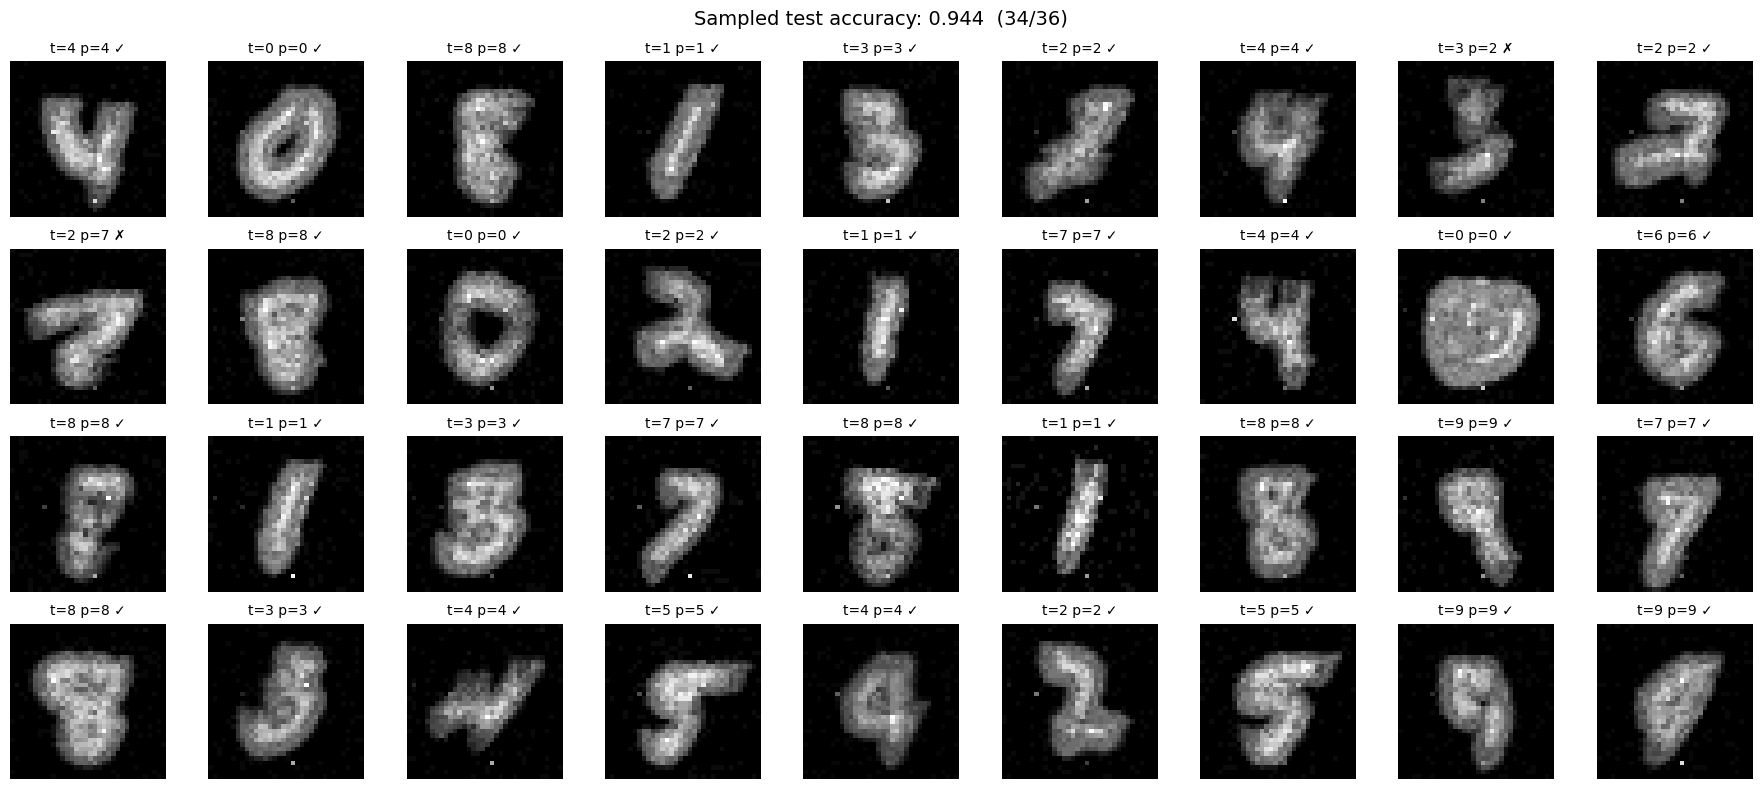

In [39]:
# --- settings ---
N = 36                 # number of examples to display
COLS = 9               # columns in the grid
SEED = 1               # reproducibility
USE_RANDOM = True      # random samples (True) or first N (False)

# --- pick indices ---
rng = np.random.default_rng(SEED)
if USE_RANDOM:
    idxs = rng.choice(len(test_ds), size=N, replace=False).tolist()
else:
    idxs = list(range(N))

rows = math.ceil(N / COLS)

fig, axes = plt.subplots(rows, COLS, figsize=(2.0 * COLS, 2.0 * rows))
axes = np.array(axes).reshape(-1)  # flatten even if rows=1

correct = 0

with torch.no_grad():
    for ax, idx in zip(axes, idxs):
        frames, y_true = test_ds[idx]             # [T,C,H,W]
        x = frames.unsqueeze(0).to(device)        # [1,T,C,H,W]

        spk_out, _ = model(x)                     # [1,T,10]
        rates = spk_out.mean(dim=1).squeeze(0)    # [10]
        y_pred = int(rates.argmax().item())

        ok = (y_pred == y_true)
        correct += int(ok)

        # Collapse across time and polarity for visualization: [H,W]
        img = frames.sum(dim=0).sum(dim=0).cpu().numpy()

        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"t={y_true} p={y_pred} {'✓' if ok else '✗'}",
            fontsize=10
        )

    # Hide any unused axes (if grid > N)
    for ax in axes[len(idxs):]:
        ax.axis("off")

acc = correct / len(idxs)
fig.suptitle(f"Sampled test accuracy: {acc:.3f}  ({correct}/{len(idxs)})", fontsize=14)
plt.tight_layout()
plt.show()